In [7]:
import numpy as np #Numerical calculation
import matplotlib.pyplot as plt   # 2D display
from scipy.integrate import odeint   #differential system solving

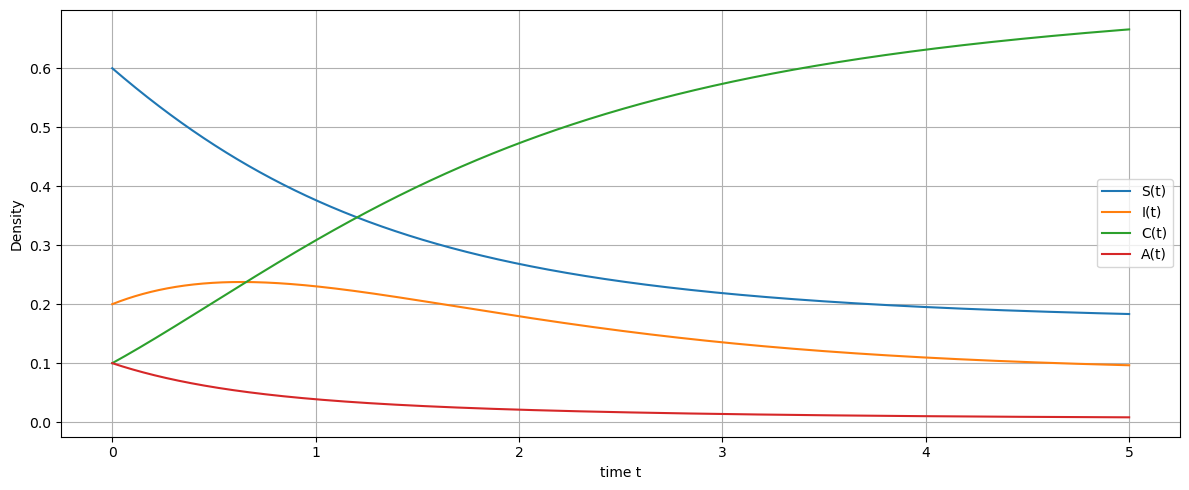

In [8]:
# system

def model(y, t, Lambda, beta, nc, na, mu, rho, phi, alpha, omega, d):
    S, I, C, A = y
    N = S + I + C + A
    lambda_t = (beta/N) * (I + nc*C + na*A)
    dSdt = Lambda - lambda_t * S - mu * S 
    dIdt = lambda_t * S - (rho + phi + mu) * I + alpha * A + omega * C
    dCdt = phi * I - (omega + mu) * C
    dAdt = rho * I - (alpha + mu + d) * A
    return [dSdt, dIdt, dCdt, dAdt]

# Parameters

mu = 1.0/69.54
Lambda = 2.1 * mu
beta = 1.6
nc = 0.015
na = 1.3
rho = 0.1
phi = 1.0
alpha = 0.33
omega = 0.09
d = 1.0

t = np.linspace(0, 5, 2000) 

#initial condition
y0 = [0.6, 0.2, 0.1, 0.1]

plt.figure(figsize=(12, 5))

sol = odeint(model, y0, t, args=(Lambda, beta, nc, na, mu, rho, phi, alpha, omega, d))
S, I, C, A = sol.T

plt.plot(t, S, label="S(t)")
plt.plot(t, I, label="I(t)")
plt.plot(t, C, label="C(t)")
plt.plot(t, A, label="A(t)")
plt.xlabel("time t")
plt.ylabel("Density")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()